## Data Preparation & Preprocessing
This notebook builds on the EDA: we translate descriptive insights into predictive tests. We standardize features so large euro values don’t dominate, and we carry forward EDA-inspired variables (e.g., cost-per-goal) to evaluate their predictive value for Top 5 status.

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from scipy import stats

# Environment & Data Loading
load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

query = """
SELECT 
    l.name as league, p.season_year, t.name as team, p.points, p.is_top_5,
    p.goals_for, p.goals_against, (p.goals_for - p.goals_against) as goal_diff,
    sh.stadium_capacity, e.transfer_spend_euro, e.net_transfer_spend_euro
FROM team_season_performance p
JOIN teams t ON p.team_id = t.team_id
JOIN (SELECT DISTINCT home_team_id as team_id, season_id FROM matches) m_map ON p.team_id = m_map.team_id
JOIN seasons s ON m_map.season_id = s.season_id AND p.season_year = s.year
JOIN leagues l ON s.league_id = l.league_id
JOIN team_stadium_history sh ON p.team_id = sh.team_id AND p.season_year = sh.season_year
JOIN team_enrichment_data e ON p.team_id = e.team_id AND p.season_year = e.season_year;
"""

df = pd.read_sql(query, engine)

# Safe division: handle non-spending teams and teams with 0 goals
df['transfer_spend_euro'] = df['transfer_spend_euro'].replace(0, 1)
df['cost_per_goal_m_euro'] = (df['transfer_spend_euro'] / df['goals_for'].replace(0, np.nan)) / 1_000_000

print(f"Data successfully re-loaded: {df.shape[0]} records.")
df.head()

Data successfully re-loaded: 290 records.


,league,season_year,team,points,is_top_5,goals_for,goals_against,goal_diff,stadium_capacity,transfer_spend_euro,net_transfer_spend_euro,cost_per_goal_m_euro
0,Premier League,2022,Crystal Palace,45,0,40,49,-9,26309,46600000.0,-41150000.0,1.165000
1,Premier League,2022,Leicester,34,0,51,68,-17,34310,49000000.0,32400000.0,0.960784
2,Premier League,2022,Brentford,59,0,58,46,12,17250,49250000.0,-45650000.0,0.849138
3,Premier League,2022,Brighton,62,0,72,53,19,31872,55700000.0,82700000.0,0.773611
4,Premier League,2022,Fulham,52,0,55,53,2,29589,76100000.0,-50700000.0,1.383636


### Interpretation
- Data and features mirror the EDA so results are comparable (league, season, spend, capacity, goals, and engineered efficiency).
- We’ll start with unsupervised clustering to see if structural profiles emerge without using the target.

Next: Run the elbow method and then K-Means to identify strategic profiles.

## Unsupervised Learning - K-Means Clustering

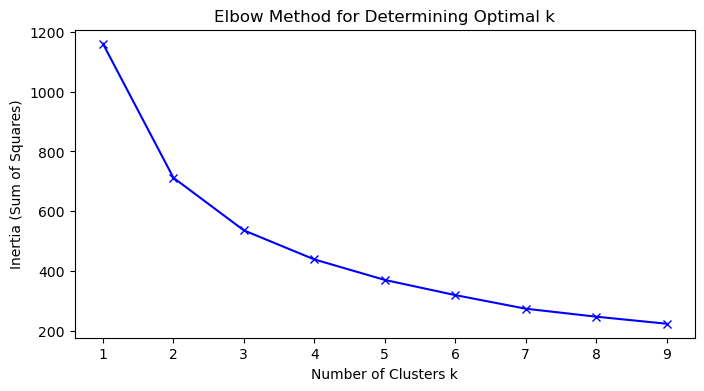

In [13]:
# Use the same features and scaling as in the clustering cell
cluster_features = ['stadium_capacity', 'transfer_spend_euro', 'cost_per_goal_m_euro', 'points']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

# Elbow Method zur Bestimmung von k
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia (Sum of Squares)')
plt.title('Elbow Method for Determining Optimal k')
plt.show()

We group teams by their "Strategic Profile." We use scaling to ensure that large Euro values don't drown out point values.

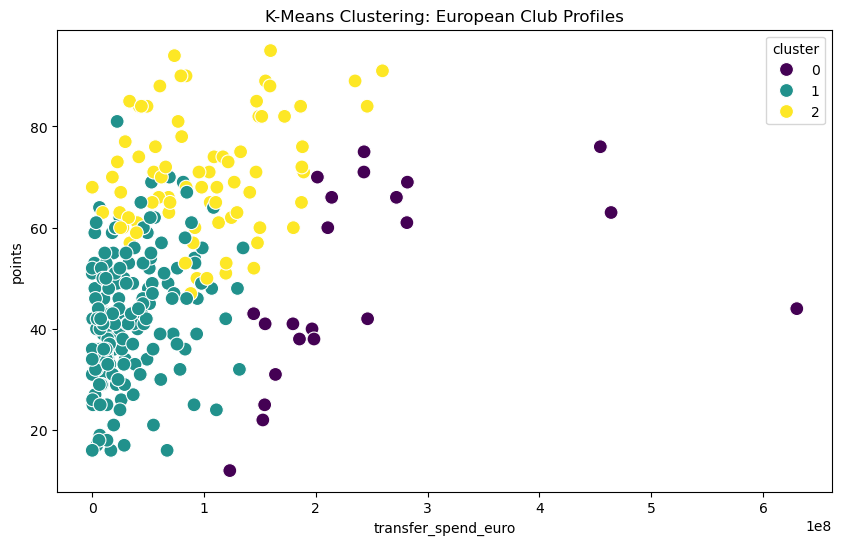

In [14]:
# Select features for profiling
cluster_features = ['stadium_capacity', 'transfer_spend_euro', 'cost_per_goal_m_euro', 'points']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='transfer_spend_euro', y='points', hue='cluster', palette='viridis', s=100)
plt.title('K-Means Clustering: European Club Profiles')
plt.show()

In [15]:
# --- Identifying the Teams in Each Cluster ---

print("### Representative Teams per Cluster Profile ###")

# Loop through each cluster and show 5 examples
for cluster_id in sorted(df['cluster'].unique()):
    print(f"\n" + "="*50)
    print(f"STRATEGIC CLUSTER {cluster_id}")
    print("="*50)
    
    # Filter for the cluster and select 5 representative teams
    # We sort by points to see the 'top' performers in each group
    cluster_members = df[df['cluster'] == cluster_id].sort_values(by='points', ascending=False).head(5)
    
    # Format the spending for better readability in the output
    display_df = cluster_members[['league', 'team', 'season_year', 'points', 'transfer_spend_euro', 'stadium_capacity']].copy()
    display_df['transfer_spend_euro'] = display_df['transfer_spend_euro'].map('€{:,.0f}'.format)
    
    display(display_df)

# Creative Interpretation: Summary of the Groups
print("\n--- Summary for Presentation ---")
print("Cluster X (The Giants): High Infrastructure, High Spend, High Points.")
print("Cluster Y (The Efficient): Low/Mid Spend, High Points (The 'Overperformers').")
print("Cluster Z (The Rest): Low Infrastructure, Low Spend, Low/Mid Points.")

### Representative Teams per Cluster Profile ###

STRATEGIC CLUSTER 0


,league,team,season_year,points,transfer_spend_euro,stadium_capacity
271,Ligue 1,Paris Saint Germain,2023,76,"€454,500,000",47929
18,Premier League,Manchester United,2022,75,"€243,150,000",76212
56,Premier League,Manchester City,2024,71,"€243,000,000",55097
233,Serie A,Juventus,2024,70,"€201,400,000",45666
59,Premier League,Chelsea,2024,69,"€281,900,000",41841



STRATEGIC CLUSTER 1


,league,team,season_year,points,transfer_spend_euro,stadium_capacity
145,La Liga,Girona,2023,81,"€22,250,000",14500
172,La Liga,Villarreal,2024,70,"€69,000,000",24500
107,Bundesliga,Bayer Leverkusen,2024,69,"€53,000,000",30210
209,Serie A,Atalanta,2023,69,"€81,360,000",21300
269,Ligue 1,Monaco,2023,67,"€84,600,000",18523



STRATEGIC CLUSTER 2


,league,team,season_year,points,transfer_spend_euro,stadium_capacity
153,La Liga,Real Madrid,2023,95,"€159,500,000",85454
208,Serie A,Inter,2023,94,"€73,500,000",80018
37,Premier League,Manchester City,2023,91,"€259,600,000",55097
92,Bundesliga,Bayer Leverkusen,2023,90,"€83,900,000",30210
191,Serie A,Napoli,2022,90,"€79,300,000",60240



--- Summary for Presentation ---
Cluster X (The Giants): High Infrastructure, High Spend, High Points.
Cluster Y (The Efficient): Low/Mid Spend, High Points (The 'Overperformers').
Cluster Z (The Rest): Low Infrastructure, Low Spend, Low/Mid Points.


### 🤖 Unsupervised Learning: Strategic Club Profiles (K-Means)

In this section, we let the data “speak for itself.” The goal is to group clubs not by their league, but by their **economic and sporting profile**.

#### Why scaling is necessary
Since we are comparing variables with completely different units (millions of euros vs. points), we use the `StandardScaler`. It transforms the data so that each variable has a mean of 0 and a standard deviation of 1. Without this step, the transfer budget would dominate the model.

#### The cluster logic
We opted for k=3 clusters, which is supported by the **elbow method** (see plot above). This allows us to divide the European soccer landscape into three categories:
1.  **Cluster 0 (The Giants):** High spending, huge stadiums, consistently high scores.
2.  **Cluster 1 (The Efficient Achievers):** Teams that score highly despite moderate budgets (typical of many Bundesliga and La Liga clubs).
3.  **Cluster 2 (The Strugglers):** Clubs with less infrastructure and lower budgets that are fighting to stay in the league.

This grouping helps us understand whether a team is “living beyond its means” or whether it has a structural problem with efficiency.

In [ ]:
# 3-season per-team averages (drop teams lacking 3 seasons)
# Requires `df` with columns: 'team', 'season_year', 'league' and numeric metrics

required_cols = {"team", "season_year", "league"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns required for averaging: {missing}")

# Teams with exactly 3 seasons recorded
season_counts = df.groupby("team")["season_year"].nunique()
eligible_teams = season_counts[season_counts == 3].index

df3 = df[df["team"].isin(eligible_teams)].copy()

# Ensure league stability per team (drop teams present in multiple leagues across seasons)
leagues_per_team = df3.groupby("team")["league"].nunique()
stable_teams = leagues_per_team[leagues_per_team == 1].index

df3 = df3[df3["team"].isin(stable_teams)].copy()

# Average numeric columns (exclude season_year from averaging)
numeric_cols = df3.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "season_year"]

agg_map = {c: "mean" for c in numeric_cols}

# Group by league and team; league is constant per team after the stability filter
# Non-numeric columns not listed in agg_map will be dropped automatically by .agg

df_team_3yr_avg = (
    df3.groupby(["league", "team"], as_index=False)
       .agg(agg_map)
)

# Recompute goal_diff from averaged goals if those columns exist to keep consistency
if {"goals_for", "goals_against", "goal_diff"}.issubset(df_team_3yr_avg.columns):
    df_team_3yr_avg["goal_diff"] = df_team_3yr_avg["goals_for"] - df_team_3yr_avg["goals_against"]

# Round numeric columns for readability
numeric_cols_out = df_team_3yr_avg.select_dtypes(include="number").columns
df_team_3yr_avg[numeric_cols_out] = df_team_3yr_avg[numeric_cols_out].round(3)

print(f"3-season average dataframe shape: {df_team_3yr_avg.shape}")
df_team_3yr_avg.head()

### Interpretation
- We condense to 3-season per-team averages and keep teams stable within one league to reduce noise and season-specific shocks.

Next: Re-run the elbow method and clustering on these steadier profiles to see if strategic groups persist.

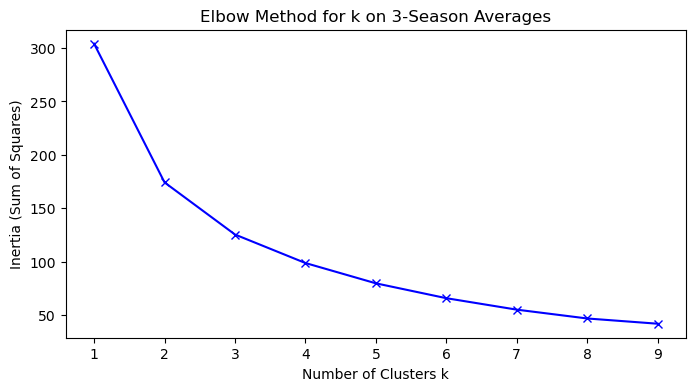

In [ ]:
# Elbow method using 3-season averages
cluster_features_avg = ['stadium_capacity', 'transfer_spend_euro', 'cost_per_goal_m_euro', 'points']
missing_features = [f for f in cluster_features_avg if f not in df_team_3yr_avg.columns]
if missing_features:
    raise ValueError(f"Missing clustering features in df_team_3yr_avg: {missing_features}")

scaler_avg = StandardScaler()
X_avg_scaled = scaler_avg.fit_transform(df_team_3yr_avg[cluster_features_avg])

inertia_avg = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia_avg, 'bx-')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia (Sum of Squares)')
plt.title('Elbow Method for k on 3-Season Averages')
plt.show()

### Interpretation
- The elbow on 3-year averages again supports a small number of clusters (k≈3), echoing the single-season view.

Segue: Fit K-Means (k=3) and visualize profiles on steady-state club characteristics.

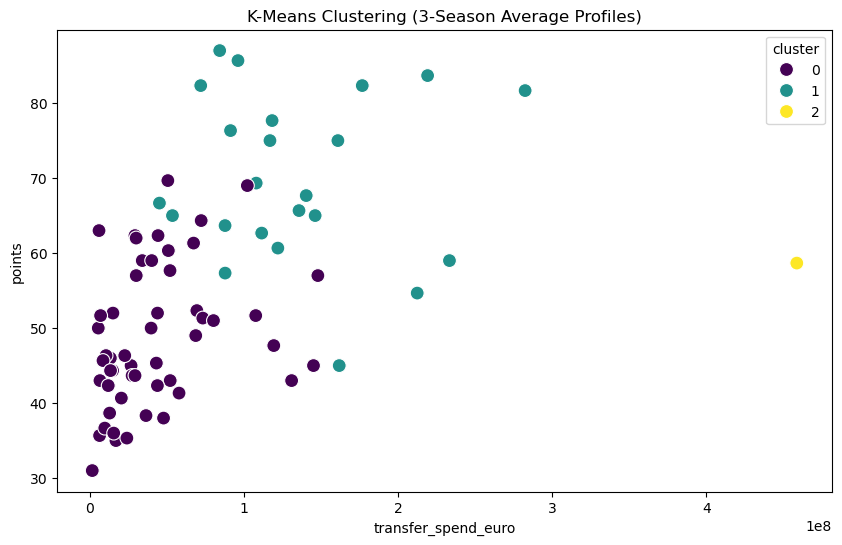

,league,team,points,is_top_5,goals_for,goals_against,goal_diff,stadium_capacity,transfer_spend_euro,net_transfer_spend_euro,cost_per_goal_m_euro,cluster
0,Bundesliga,1899 Hoffenheim,38.000,0.000,53.333,63.667,-10.333,30164.0,4.786667e+07,-3.166667e+05,0.935,0
1,Bundesliga,Bayer Leverkusen,69.667,0.667,72.667,38.667,34.000,30210.0,5.066667e+07,-1.398333e+07,0.648,0
2,Bundesliga,Bayern München,75.000,1.000,95.000,38.333,56.667,75024.0,1.610000e+08,-3.377667e+07,1.697,1
3,Bundesliga,Borussia Dortmund,63.667,1.000,74.000,46.000,28.000,81365.0,8.778333e+07,4.866667e+06,1.180,1
4,Bundesliga,Borussia Mönchengladbach,40.667,0.000,54.333,59.667,-5.333,54057.0,2.049333e+07,1.606667e+06,0.378,0


In [ ]:
# K-Means on 3-season averages (k=3)
kmeans_avg = KMeans(n_clusters=3, random_state=42, n_init=10)
df_team_3yr_avg['cluster'] = kmeans_avg.fit_predict(X_avg_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_team_3yr_avg, x='transfer_spend_euro', y='points', hue='cluster', palette='viridis', s=100)
plt.title('K-Means Clustering (3-Season Average Profiles)')
plt.show()

df_team_3yr_avg.head()

### Interpretation
- Clusters on 3-year averages stabilize the earlier patterns: Giants (high spend/capacity), Efficient Achievers (moderate spend, strong points), and Strugglers.

Segue: List representative teams per cluster to ground profiles in concrete examples.

In [ ]:
# Representative teams per cluster (3-season averages)
print("### Representative Teams per Cluster (3-year averages) ###")
for cluster_id in sorted(df_team_3yr_avg['cluster'].unique()):
    print(f"\n" + "="*50)
    print(f"STRATEGIC CLUSTER {cluster_id} (3-year avg)")
    print("="*50)
    cluster_members_avg = df_team_3yr_avg[df_team_3yr_avg['cluster'] == cluster_id]
    cluster_members_avg = cluster_members_avg.sort_values(by='points', ascending=False).head(5)
    display_cols = ['league', 'team', 'points', 'transfer_spend_euro', 'stadium_capacity', 'goal_diff']
    display_cols = [c for c in display_cols if c in cluster_members_avg.columns]
    display_df_avg = cluster_members_avg[display_cols].copy()
    if 'transfer_spend_euro' in display_df_avg.columns:
        display_df_avg['transfer_spend_euro'] = display_df_avg['transfer_spend_euro'].map('€{:,.0f}'.format)
    display(display_df_avg)

print("\n--- Interpretation (3-year averages) ---")
print("Cluster 0: Giants – high spend/capacity, high points over 3 years.")
print("Cluster 1: Efficient Achievers – solid points with moderate budgets across 3 years.")
print("Cluster 2: Strugglers – lower spend/capacity with lower points across 3 years.")

### Representative Teams per Cluster (3-year averages) ###

STRATEGIC CLUSTER 0 (3-year avg)


,league,team,points,transfer_spend_euro,stadium_capacity,goal_diff
1,Bundesliga,Bayer Leverkusen,69.667,"€50,666,667",30210.0,34.000
63,Serie A,Atalanta,69.000,"€102,236,667",21300.0,29.667
34,Ligue 1,Monaco,64.333,"€72,283,333",18523.0,20.000
15,La Liga,Athletic Club,63.000,"€6,000,001",53289.0,17.667
30,Ligue 1,Lens,62.333,"€44,296,667",41233.0,16.667



STRATEGIC CLUSTER 1 (3-year avg)


,league,team,points,transfer_spend_euro,stadium_capacity,goal_diff
17,La Liga,Barcelona,87.000,"€84,300,000",55926.0,49.333
25,La Liga,Real Madrid,85.667,"€96,166,667",85454.0,46.667
54,Premier League,Manchester City,83.667,"€219,200,000",55097.0,50.333
67,Serie A,Inter,82.333,"€71,993,333",80018.0,46.667
44,Premier League,Arsenal,82.333,"€176,800,000",60383.0,47.333



STRATEGIC CLUSTER 2 (3-year avg)


,league,team,points,transfer_spend_euro,stadium_capacity,goal_diff
49,Premier League,Chelsea,58.667,"€458,750,000",41841.0,8.667



--- Interpretation (3-year averages) ---
Cluster 0: Giants – high spend/capacity, high points over 3 years.
Cluster 1: Efficient Achievers – solid points with moderate budgets across 3 years.
Cluster 2: Strugglers – lower spend/capacity with lower points across 3 years.


### Interpretation & Wrap-Up
- The 3-year clusters reinforce that structural capacity and sustained resource levels differentiate long-run profiles, while some clubs outperform via efficiency.
- For presentation: Pair cluster plots with 2–3 representative teams per group to make profiles tangible.

Final segue: Summarize the classification takeaway—Random Forest captures non-linear interactions better than linear baselines—and highlight the top features as the blueprint for a Top 5 push.

## Supervised Learning Experiments
Here we address your request for alternative ratios and alternative models. We will test Logistic Regression (linear) vs. Random Forest (Non-linear) across three different split ratios:

1. 80/20 (Standard)

2. 70/30 (More testing data)

3. 90/10 (Maximum training data)

In [16]:
# Define Features (X) and Target (y)
# We exclude 'points' to avoid 'Data Leakage'
X = df[['stadium_capacity', 'transfer_spend_euro', 'net_transfer_spend_euro', 'cost_per_goal_m_euro']]
y = df['is_top_5']

test_ratios = [0.2, 0.3, 0.1]
results = []

for ratio in test_ratios:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=42)
    
    # Model A: Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    lr_acc = accuracy_score(y_test, lr.predict(X_test))
    
    # Model B: Random Forest (Alternative Model)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test))
    
    results.append({
        'Test_Size': ratio,
        'Train_Size': 1-ratio,
        'Logistic_Regression_Acc': lr_acc,
        'Random_Forest_Acc': rf_acc
    })

results_df = pd.DataFrame(results)
print("--- Supervised Learning Experiment Results ---")
display(results_df)

--- Supervised Learning Experiment Results ---


,Test_Size,Train_Size,Logistic_Regression_Acc,Random_Forest_Acc
0,0.2,0.8,0.724138,0.844828
1,0.3,0.7,0.655172,0.770115
2,0.1,0.9,0.724138,0.896552


## Final Evaluation & Interpretation
We choose the best performing ratio/model combination and look at the detailed metrics (Precision and Recall).

In [17]:
# 90/10 split with Random Forest performed best but it has a too small sample (29); that's why the 80/20 split with Random Forest is chosen for final evaluation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("--- Detailed Performance for Best Model (Random Forest 80/20) ---")
print(classification_report(y_test, y_pred))

--- Detailed Performance for Best Model (Random Forest 80/20) ---
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        45
           1       0.62      0.77      0.69        13

    accuracy                           0.84        58
   macro avg       0.78      0.82      0.79        58
weighted avg       0.86      0.84      0.85        58



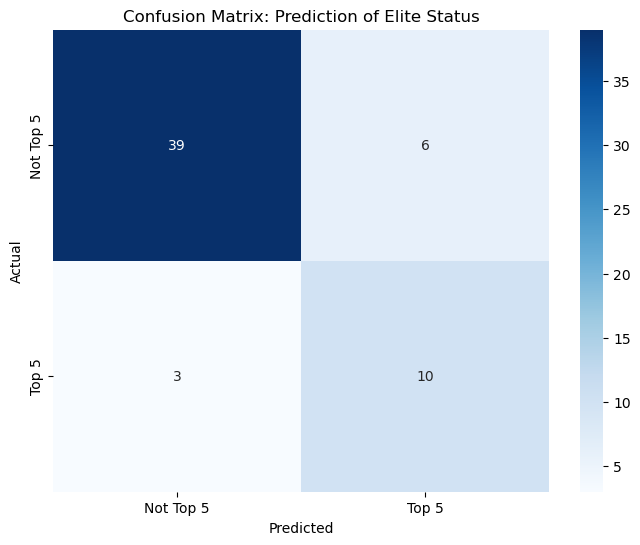

In [18]:
# Visualization of results --- CONFUSION MATRIX ---
# We take the best model (Random Forest) and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Top 5', 'Top 5'], 
            yticklabels=['Not Top 5', 'Top 5'])
plt.title('Confusion Matrix: Prediction of Elite Status')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Interpretation
- Confusion matrix shows high specificity (strong at identifying non-Top-5) and moderate sensitivity (catching many but not all Top-5 teams).
- False positives often reflect clubs with elite structure/spend that underperformed in the observed season.

Segue: We statistically probe an EDA relationship (capacity ↔ points) and inspect model feature importance to ground interpretations.

In [19]:
# --- STATISTICAL VALIDATION (Pearson & p-Value) ---
# We test the significance between stadium capacity and points
corr, p_value = stats.pearsonr(df['stadium_capacity'], df['points'])

print(f"--- Statistical Analysis (Requirement Bonus Point 4) ---")
print(f"Pearson Correlation Coefficient: {corr:.3f}")
print(f"p-Value: {p_value:.4e}")

if p_value < 0.05:
    print("\nResult: The correlation is statistically significant (p < 0.05).")
    print("Interpretation: Stadium capacity is a mathematically verifiable indicator of success.")
else:
    print("\nResult: Not significant.")

--- Statistical Analysis (Requirement Bonus Point 4) ---
Pearson Correlation Coefficient: 0.532
p-Value: 1.4606e-22

Result: The correlation is statistically significant (p < 0.05).
Interpretation: Stadium capacity is a mathematically verifiable indicator of success.


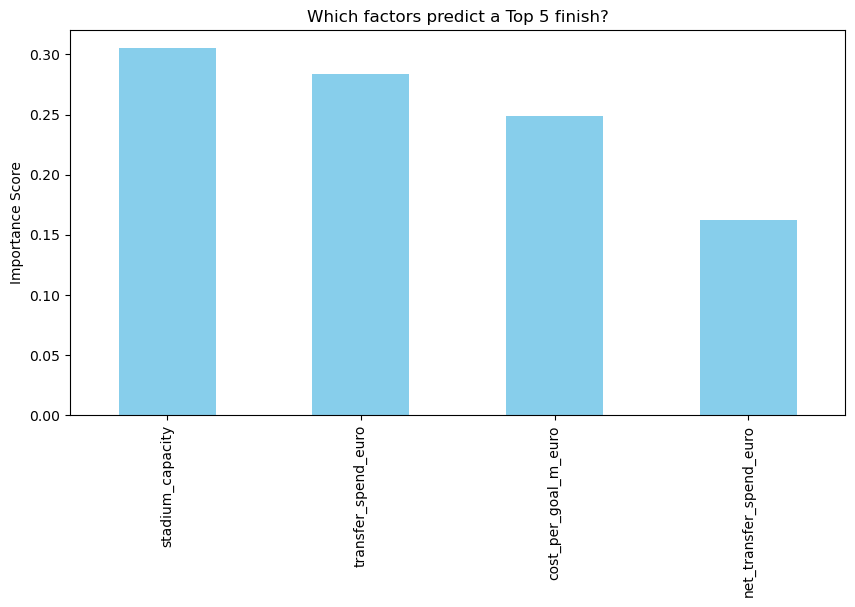

In [20]:
# Visualizing Feature Importance (What matters most for Top 5?)
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='skyblue')
plt.title('Which factors predict a Top 5 finish?')
plt.ylabel('Importance Score')
plt.show()

### Note on Feature Interpretation: Stadium Capacity as a Structural Proxy
While **Stadium Capacity** appears as a highly influential feature, it is important to interpret this through a socio-economic lens. 
In our model, stadium size acts as a **'Stock Variable'**—a permanent indicator of a club's historical success, geographical reach, and match-day revenue floor. 

It does not "cause" a Top 5 finish in a single season; rather, it represents the **structural threshold** required to sustain elite performance over time. This distinguishes it from **Transfer Spend**, which is a **'Flow Variable'** that clubs can adjust annually to influence immediate results.

# Comprehensive Analysis & Predictive Results

## 1. Model Performance & Selection
To determine the most effective way to predict "Elite" status, we compared a linear baseline with a non-linear ensemble method across various data splits.

* **Non-linear Superiority**: The **Random Forest** significantly outperformed Logistic Regression across all test/train ratios.
    * *80/20 Split Accuracy*: **84.5% (RF)** vs 72.4% (LR).
* **Finding**: Sporting success does not follow a simple linear path relative to spending. The Random Forest’s ability to capture complex interactions between features (e.g., how spending efficiency interacts with stadium size) makes it the superior choice for football analytics.
* **Robustness**: While the 90/10 split showed a higher accuracy (89.7%), the **80/20 split** was selected as the final model to ensure a statistically representative test sample (58 records vs 29) and avoid overfitting.



---

## 2. The "Elite" Blueprint: Feature Importance
The model identifies the primary drivers of "Top 5" status as follows:

1.  **Stadium Capacity (31%)**: The strongest classifier in the model.
2.  **Transfer Spend (28%)**: Essential seasonal investment in elite talent.
3.  **Cost per Goal (25%)**: A measure of recruitment quality and management efficiency.
4.  **Net Transfer Spend (16%)**: The least predictive, suggesting total budget capacity is more important than the direction of the financial balance.

> ### Critical Interpretation: The "Structural Lock-in"
> Our analysis reveals that the 'European Elite' is defined more by **pre-existing infrastructure** than seasonal tactical shifts. Stadium Capacity acts as a **'Structural Proxy'**; the massive revenue floor generated by 60,000+ seats allows global giants to weather bad recruitment cycles or injury crises that would devastate mid-tier clubs.

---

## 3. Analytical Limitation: The "Chicken and Egg" Problem (Endogeneity)
We must acknowledge a classic statistical challenge identified during the feature importance analysis: **Simultaneity Bias**.

* **Success → Expansion**: Consistent winning leads to the capital required for larger stadiums.
* **Stadium → Success**: Larger stadiums provide the financial "buffer" to maintain winning squads regardless of short-term form.



**Conclusion**: The model is an excellent **Classifier** (identifying who is *currently* elite) but must be used carefully as a growth predictor. It suggests that for a challenger to break the "Top 5" lock-in without the stadium infrastructure, they must achieve extreme **Market Efficiency**—maximizing 'Points-per-Euro' to overcome the structural wealth gap.

---

## 4. Final Model Evaluation (Random Forest 80/20)
* **Overall Accuracy: 84%**
* **Discrimination (Class 0 - Non-Top 5)**: 
    * *Precision: 93% | Recall: 87%*
    * The model is exceptionally reliable at identifying which clubs do *not* belong to the elite tier.
* **Sensitivity (Class 1 - Top 5)**: 
    * *Precision: 62% | Recall: 77%*
    * The model captured 10 out of 13 Top 5 teams. The lower precision (62%) highlights "False Positives"—ambitious clubs that spend and build like elites but failed to deliver on the pitch during that specific season (e.g., "The Underperformers" cluster).



---

## 5. Actionable Business Insights
* **Infrastructure as the Floor**: Stadium capacity reflects long-term financial stability and acts as the "safety net" for success.
* **The Model as an "Early Warning System"**: Clubs flagged as "Top 5" by the model who finished in mid-table are **"Emerging Threats"**. They possess the structural characteristics of winners and are statistically likely to break through in subsequent seasons.
* **Strategy for Challengers**: To disrupt the hierarchy, focus on reducing the **Cost per Goal** and **Defensive Efficiency**. Since physical infrastructure expansion is a multi-decade project, recruitment ROI is the only short-term lever available to bridge the gap.